# <u>Same code as in the previous notebook:</u>

In [11]:
# Comment the following lines if you're not in colab:
from google.colab import drive
drive.mount('/content/drive')
# If you're in colab, cd to your own working directory here:
%cd ..//..//content//drive//MyDrive//Colab-Notebooks//HY-673-Tutorials//Tutorial-4

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[Errno 2] No such file or directory: '..//..//content//drive//MyDrive//Colab-Notebooks//HY-673-Tutorials//Tutorial-4'
/content/drive/MyDrive/Colab-Notebooks/HY-673-Tutorials/Tutorial-4


In [12]:
!pip install torchinfo

In [13]:
import matplotlib.pyplot as plt

import torch as tc
import torch.nn as nn
import torch.nn.functional as F
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from torchinfo import summary

In [14]:
device = tc.device("cuda" if tc.cuda.is_available() else "cpu")
figsize_ = (3,3)

In [15]:
class SimpleCNN(nn.Module):

    def __init__(self, n_classes=10):
        super(SimpleCNN, self).__init__()

        self.n_classes = n_classes

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=16,
            kernel_size=3,
            stride=1,
            padding=1,
            dilation=1
        )
        self.conv2 = nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=3,
            stride=1,
            padding=1,
            dilation=1
        )
        self.conv3 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=2,
            stride=1,
            padding=1,
            dilation=2
        )
        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )  # non-parametric, same object can be used

        self.fc1 = nn.Linear(
            in_features=64*3*3,
            out_features=32
        )
        self.fc2 = nn.Linear(
            in_features=32,
            out_features=self.n_classes
        )

    def forward(self, x):          # dimension analysis:
        x = F.relu(self.conv1(x))  # 1x28x28  --> 16x28x28
        x = self.pool(x)           # 16x28x28 --> 16x14x14
        x = F.relu(self.conv2(x))  # 16x14x14 --> 32x14x14
        x = self.pool(x)           # 32x14x14 --> 32x7x7
        x = F.relu(self.conv3(x))  # 32x7x7   --> 64x7x7
        x = self.pool(x)           # 64x7x7   --> 64x3x3
        x = x.view(-1, 64 * 3 * 3) # 64x3x3   --> 64*3*3
        x = F.relu(self.fc1(x))    # 64*3*3   --> 32
        x = self.fc2(x)            # 32       --> 10
        return x

In [16]:
datapath = 'data'

data_train = MNIST(
    root = datapath,
    train = True,
    transform=  ToTensor(),
    download = True
)

digit.shape = torch.Size([1, 28, 28])


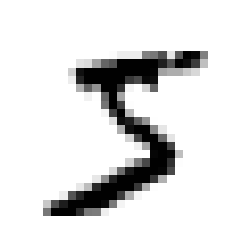

In [17]:
digit, label = data_train[0]
digit = digit.to(device)
print(f"digit.shape = {digit.shape}")

plt.figure(figsize=figsize_)
plt.imshow(digit[0].cpu(), cmap='binary')
plt.axis('off')
plt.show()
plt.close()

In [18]:
model = SimpleCNN(n_classes=10).to(device)
digit_batch = digit.unsqueeze(0)  # add batch dimension
print(summary(model, input_size=digit_batch.shape, device=device))
out = model(digit_batch)
print(f"out.shape = {out.shape}")

Layer (type:depth-idx)                   Output Shape              Param #
SimpleCNN                                [1, 10]                   --
├─Conv2d: 1-1                            [1, 16, 28, 28]           160
├─MaxPool2d: 1-2                         [1, 16, 14, 14]           --
├─Conv2d: 1-3                            [1, 32, 14, 14]           4,640
├─MaxPool2d: 1-4                         [1, 32, 7, 7]             --
├─Conv2d: 1-5                            [1, 64, 7, 7]             8,256
├─MaxPool2d: 1-6                         [1, 64, 3, 3]             --
├─Linear: 1-7                            [1, 32]                   18,464
├─Linear: 1-8                            [1, 10]                   330
Total params: 31,850
Trainable params: 31,850
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.46
Input size (MB): 0.00
Forward/backward pass size (MB): 0.18
Params size (MB): 0.13
Estimated Total Size (MB): 0.31
out.shape = torch.Size([1, 10])


# <u> Visualize Features Extracted by Convolutional Layers </u>

One main advantage of CNNs is that we can visualize the **features** extracted by convolutional layers. These layers learn **local patterns** from an image, such as edges, corners, and simple textures.  

These features can be visualized using `plt.imshow()` from Matplotlib. If you use the `'binary'` colormap, darker pixels correspond to regions that receive a higher "score" (i.e., stronger activation) by the network. You can think of these darker regions as the most relevant for the model's final prediction.

Let's create an instance of the model we used previously and check that everything works fine so far. We can load the weights that we trained from before:

In [19]:
loaded_state_dict = tc.load("saved_models/CNN.pt")
model.load_state_dict(loaded_state_dict)

<All keys matched successfully>

We now create a helper plotting function to visualize the feature maps produced by the network.

The images will be displayed in **grayscale**: pixel values closer to $-\infty$ appear darker, while values closer to $+\infty$ appear brighter. Note, however, that for each image the **minimum value is mapped to the darkest color**, since the colormap is normalized independently for every plot:

In [20]:
def plot_layer(out_features, features_per_row=8, vmin=-.5, vmax=.5):
    n_rows = len(out_features) // features_per_row
    n_tot = int(n_rows*features_per_row)
    out_features = out_features[:n_tot]
    fig = plt.figure(figsize=(features_per_row, n_rows))
    for i, out_ in enumerate(out_features):
        a = fig.add_subplot(n_rows, features_per_row, i+1)
        plt.imshow(out_, cmap='gray', vmin=vmin, vmax=vmax)
        a.axis("off")
plt.show()
plt.close()

<u>**First convolutional layer**</u>

We will feed the network with this digit sampled from the dataset and visualize the output of the first convolutional layer.

When a convolutional layer processes an image, it produces a stack of **feature maps**, one for each output channel of the layer.

This layer produces **16 output channels** and preserves the spatial resolution. Therefore, the output consists of **16 feature maps**, each of size $28 \times 28$:

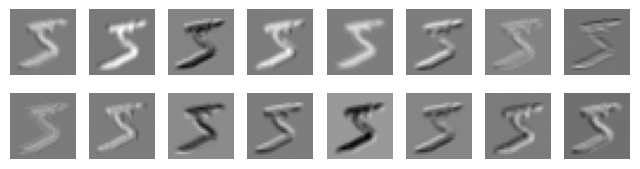

In [21]:
out_conv1 = model.conv1(digit)

# Keep the initial min and max values for color comparison reference:
minv, maxv = out_conv1.min().item(), out_conv1.max().item()

plot_layer(out_conv1.cpu().detach().numpy(), vmin=minv, vmax=maxv)

**How to read the plots**

When we apply a convolutional layer to an image, we obtain a stack of 2D outputs, one per filter. Each output is called a **feature map** (or activation map), and shows *where* and *how strongly* that filter responds.

In the visualizations, brighter pixels correspond to larger activation values, while darker pixels correspond to smaller values.

Next, let's visualize the same outputs after applying **ReLU**. Since all negative values are mapped to $0$, we should observe a much **brighter (whiter)** result overall:

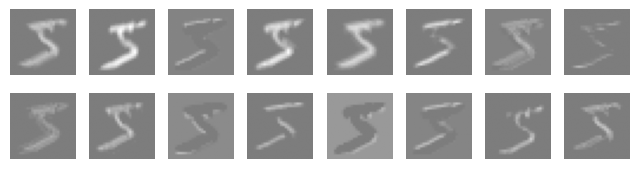

In [22]:
out_relu1 = F.relu(out_conv1)
plot_layer(out_features=out_relu1.cpu().detach().numpy(), vmin=minv, vmax=maxv)

<u>**Second convolutional layer</u> (after pooling)**

Before the second convolution, we apply max-pooling, which reduces the spatial resolution (e.g., $28 \times 28 \rightarrow 14 \times 14$).  
The second convolution then produces $32$ feature maps on this lower-resolution representation.

At this depth, feature maps are usually harder to interpret: filters start combining simpler patterns (edges/strokes) into more **composite features**, and pooling makes activations coarser in space:

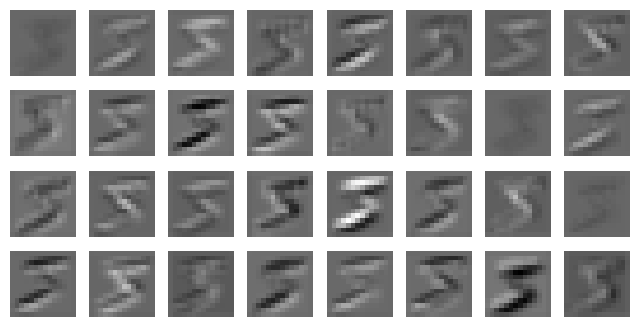

In [23]:
out_pool1 = model.pool(out_relu1)
out_conv2 = model.conv2(out_pool1)
minv, maxv = out_conv2.min().item(), out_conv2.max().item()

# Keep the initial min and max values for color comparison reference:
plot_layer(out_features=out_conv2.cpu().detach().numpy(), vmin=minv, vmax=maxv)

<u>**After applying ReLU**</u>

ReLU maps all negative activations to $0$. As a result, the feature maps become more **sparse**: only locations that strongly match a filter remain active.

Since we keep the same `vmin/vmax` as before, setting negative values to $0$ typically makes the maps look **brighter overall**, because values are shifted away from the negative range:

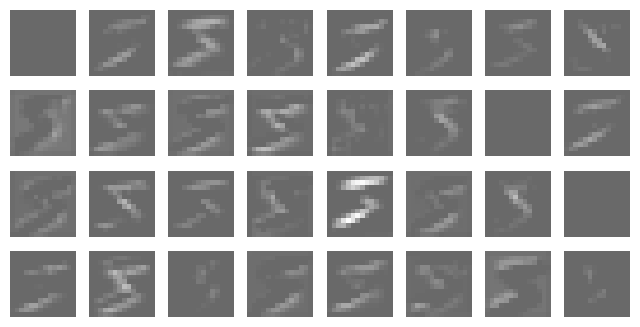

In [24]:
out_relu2 = F.relu(out_conv2)
plot_layer(out_relu2.cpu().detach().numpy(), vmin=minv, vmax=maxv)

# <u>Homework (optional)</u>

- Repeat the same visualization for the rest of the layers of the network. Does it stop being interpretable at some point?
- Another way to gain intuition is to visualize the **filters (weights)** learned by the convolutional layers. This is not always straightforward, since some filters can be difficult to interpret. Try to visualize the filters of this model and see whether you gain any useful insights. One source you may find helpful is:  
https://towardsdatascience.com/visualizing-convolution-neural-networks-using-pytorch-3dfa8443e74e